In [5]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from helper_utils import load_chroma, word_wrap
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

embedding_function = SentenceTransformerEmbeddingFunction()

chroma_collection = load_chroma(filename='sample.pdf', collection_name='sample', embedding_function=embedding_function)
chroma_collection.count()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

7

In [6]:
import umap
import numpy as np
from tqdm import tqdm

embeddings = chroma_collection.get(include=['embeddings'])['embeddings']
umap_transform = umap.UMAP(random_state=0, transform_seed=0).fit(embeddings)

In [7]:
def project_embeddings(embeddings, umap_transform):
    umap_embeddings = np.empty((len(embeddings),2))
    for i, embedding in enumerate(tqdm(embeddings)): 
        umap_embeddings[i] = umap_transform.transform([embedding])
    return umap_embeddings   

In [8]:
projected_dataset_embeddings = project_embeddings(embeddings, umap_transform)

100%|██████████| 7/7 [00:07<00:00,  1.02s/it]


(np.float64(7.8803118705749515),
 np.float64(12.252636051177978),
 np.float64(-6.551303613185882),
 np.float64(-2.2469964146614076))

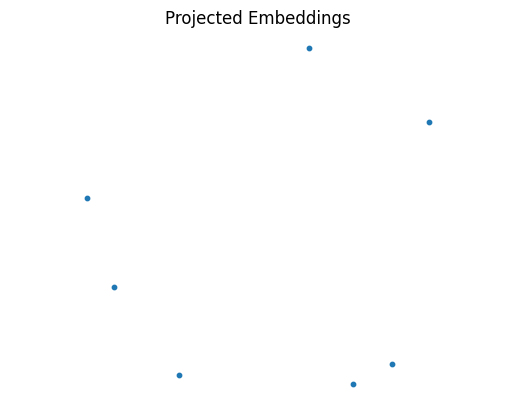

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(projected_dataset_embeddings[:, 0], projected_dataset_embeddings[:, 1], s=10)
plt.gca().set_aspect('equal', 'datalim')
plt.title('Projected Embeddings')
plt.axis('off')

In [11]:
query = "How does ChromaDB support RAG applications?"

results = chroma_collection.query(query_texts=query, n_results=5, include=['documents', 'embeddings'])

retrieved_documents = results['documents'][0]

for document in results['documents'][0]:
    print(word_wrap(document))
    print('')

architecture, where the database runs as a standalone server and
applications connect to it remotely. this makes it suitable for
deployment in cloud environments and collaborative systems where
multiple applications need access to the same data. use cases and
applications one of the most common use cases for chromadb is retrieval
- augmented generation, commonly known as rag. in a rag system, a large
language model is paired with a vector database so that it can retrieve
relevant information from a custom knowledge base before generating a
response. instead of relying solely on the information it was trained
on, the model can dynamically pull

transformers from hugging face, or any other provider. querying in
chromadb is done through a nearest - neighbor search, which finds the
vectors that are closest to a given query vector according to a
distance metric such as cosine similarity or euclidean distance. the
results include not only the most relevant documents but also their
metadata a

In [12]:
query_embedding = embedding_function([query])[0]
retrieved_embeddings = results['embeddings'][0]

projected_query_embedding = project_embeddings([query_embedding], umap_transform)
projected_retrieved_embeddings = project_embeddings(retrieved_embeddings, umap_transform)


100%|██████████| 5/5 [00:00<00:00, 145.51it/s]


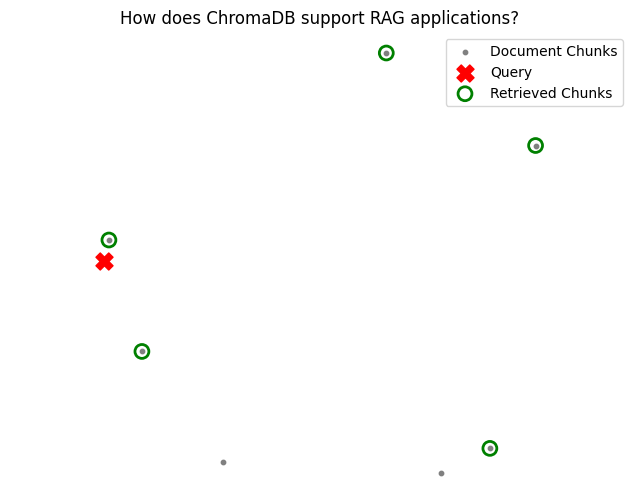

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    projected_dataset_embeddings[:, 0],
    projected_dataset_embeddings[:, 1],
    s=10,
    color='gray',
    label='Document Chunks'
)

plt.scatter(
    projected_query_embedding[:, 0],
    projected_query_embedding[:, 1],
    s=150,
    marker='X',
    color='red',
    label='Query'
)

plt.scatter(
    projected_retrieved_embeddings[:, 0],
    projected_retrieved_embeddings[:, 1],
    s=100,
    facecolors='none',
    edgecolors='green',
    linewidths=2,
    label='Retrieved Chunks'
)

plt.gca().set_aspect('equal', 'datalim')
plt.title(query)
plt.legend()
plt.axis('off')
plt.show()

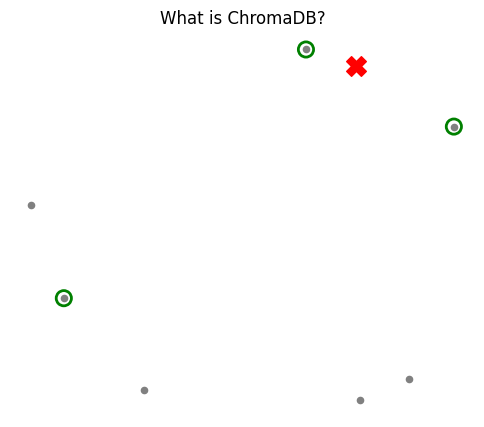

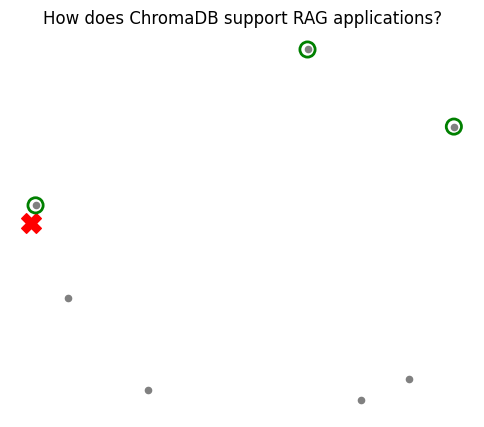

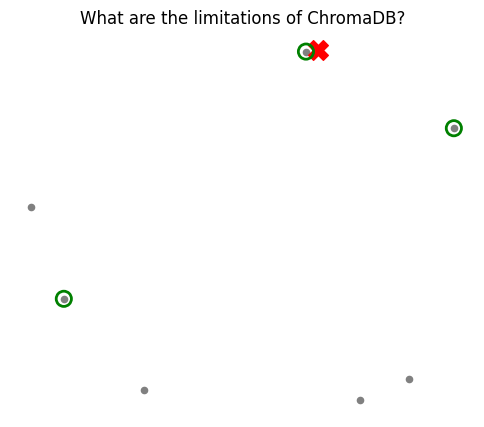

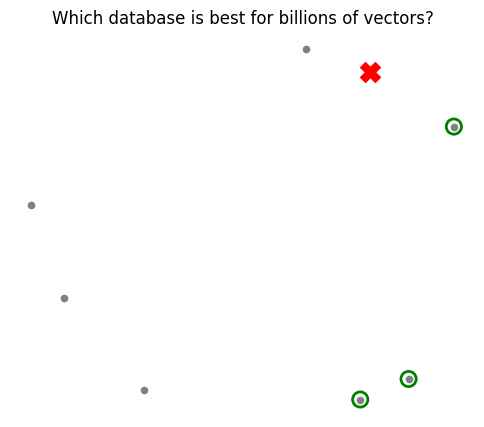

In [18]:
queries = [
    "What is ChromaDB?",
    "How does ChromaDB support RAG applications?",
    "What are the limitations of ChromaDB?",
    "Which database is best for billions of vectors?"

]

for query in queries:
    results = chroma_collection.query(
        query_texts=[query],
        n_results=3,
        include=["embeddings"]
    )

    retrieved_embeddings = np.array(results["embeddings"][0])

    query_embedding = embedding_function([query])

    projected_query = umap_transform.transform(query_embedding)
    projected_retrieved = umap_transform.transform(retrieved_embeddings)

    plt.figure(figsize=(6,5))

    plt.scatter(
        projected_dataset_embeddings[:,0],
        projected_dataset_embeddings[:,1],
        color="gray",
        s=20
    )

    plt.scatter(
        projected_query[:,0],
        projected_query[:,1],
        color="red",
        marker="X",
        s=200
    )

    plt.scatter(
        projected_retrieved[:,0],
        projected_retrieved[:,1],
        facecolors="none",
        edgecolors="green",
        s=120,
        linewidths=2
    )

    plt.title(query)
    plt.axis("off")
    plt.show()